# Netflix User Behavior & Churn Analysis

This project analyzes Netflix user behavior to understand viewing patterns, content preferences, and factors affecting user churn.

Objectives:
- Explore user demographics and device usage
- Analyze content consumption patterns
- Identify factors influencing churn
- Build a machine learning model to predict churn

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("archive/netflix_user_behavior_dataset.csv")

df.head()

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,Sci-Fi,220,17,3,60,1.7,5,66,16,No
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,Documentary,76,15,4,71,4.6,7,78,14,No
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,Comedy,215,6,13,33,2.0,27,29,41,No
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,Action,280,4,9,58,1.2,9,23,22,No
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,Horror,261,15,9,64,1.3,49,56,54,No


In [5]:
print("Dataset Shape:", df.shape)

df.info()

df.describe()

Dataset Shape: (50000, 20)
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    50000 non-null  str    
 1   age                        50000 non-null  int64  
 2   gender                     50000 non-null  str    
 3   country                    50000 non-null  str    
 4   account_age_months         50000 non-null  int64  
 5   subscription_type          50000 non-null  str    
 6   monthly_fee                50000 non-null  float64
 7   payment_method             50000 non-null  str    
 8   primary_device             50000 non-null  str    
 9   devices_used               50000 non-null  int64  
 10  favorite_genre             50000 non-null  str    
 11  avg_watch_time_minutes     50000 non-null  int64  
 12  watch_sessions_per_week    50000 non-null  int64  
 13  binge_watch_sessions       500

,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.979240,29.874000,12.323340,1.999140,154.946520,9.986920,7.002520,64.533420,3.002316,24.306380,49.563000,29.410520
std,13.528733,17.051104,3.309109,0.818238,83.727292,5.480616,4.335819,20.206377,1.152308,14.468037,28.816997,17.312414
min,18.000000,1.000000,7.990000,1.000000,10.000000,1.000000,0.000000,30.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,15.000000,7.990000,1.000000,83.000000,5.000000,3.000000,47.000000,2.000000,12.000000,25.000000,14.000000
50%,41.000000,30.000000,12.990000,2.000000,155.000000,10.000000,7.000000,65.000000,3.000000,24.000000,50.000000,29.000000
75%,53.000000,45.000000,15.990000,3.000000,228.000000,15.000000,11.000000,82.000000,4.000000,37.000000,75.000000,44.000000
max,64.000000,59.000000,15.990000,3.000000,299.000000,19.000000,14.000000,99.000000,5.000000,49.000000,99.000000,59.000000


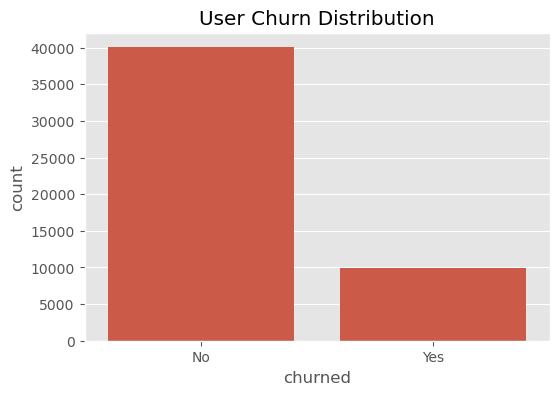

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="churned")

plt.title("User Churn Distribution")

plt.show()

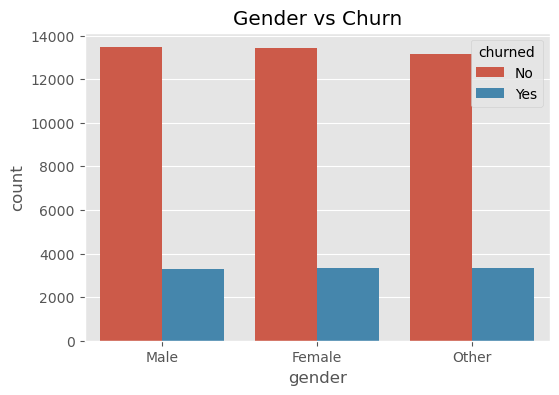

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender",
    hue="churned"
)

plt.title("Gender vs Churn")

plt.show()

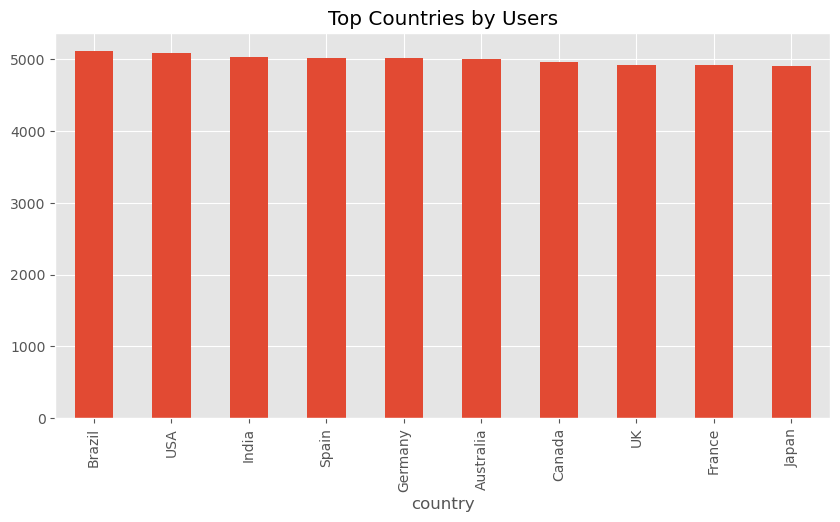

In [8]:
plt.figure(figsize=(10,5))

df["country"].value_counts().head(10).plot(kind="bar")

plt.title("Top Countries by Users")

plt.show()

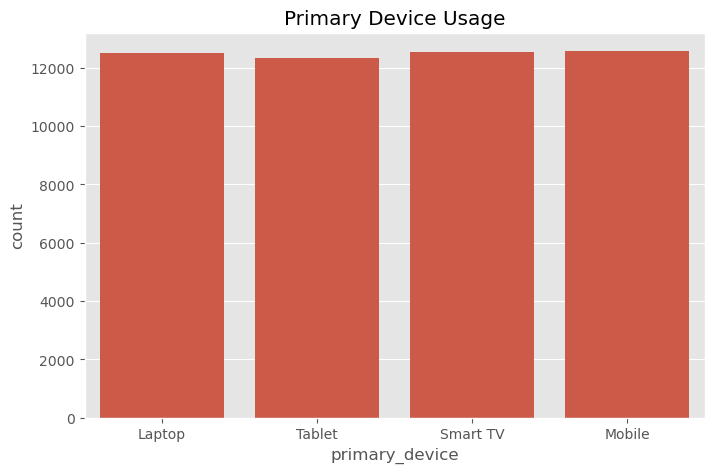

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="primary_device"
)

plt.title("Primary Device Usage")

plt.show()

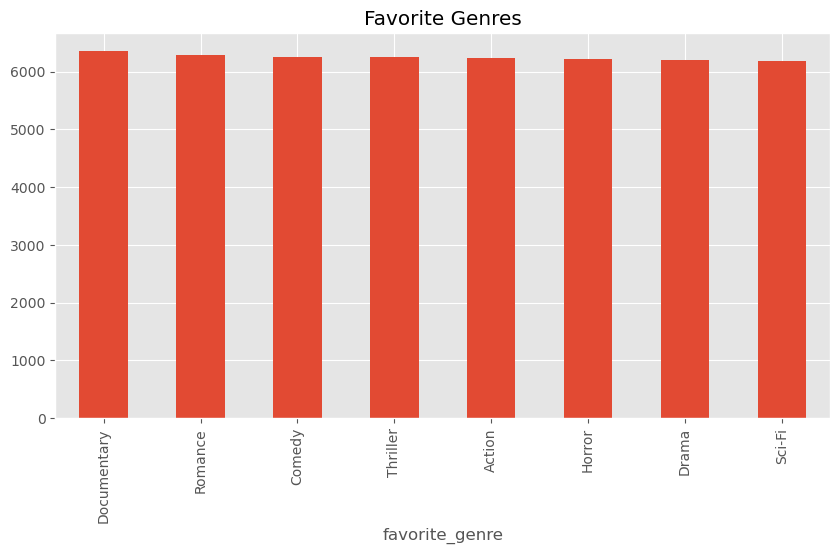

In [10]:
plt.figure(figsize=(10,5))

df["favorite_genre"].value_counts().plot(kind="bar")

plt.title("Favorite Genres")

plt.show()

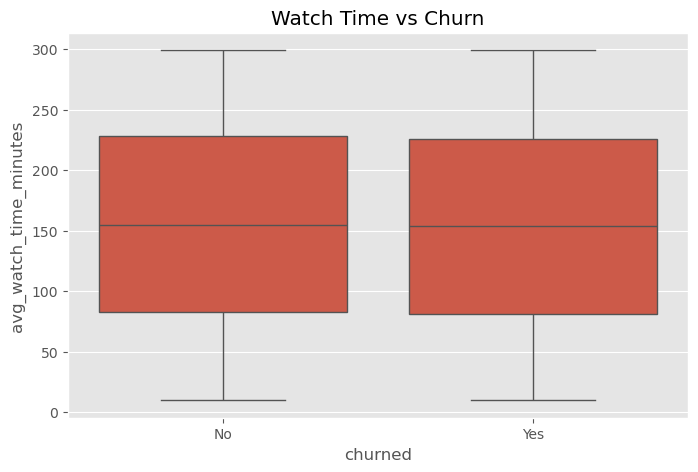

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churned",
    y="avg_watch_time_minutes"
)

plt.title("Watch Time vs Churn")

plt.show()

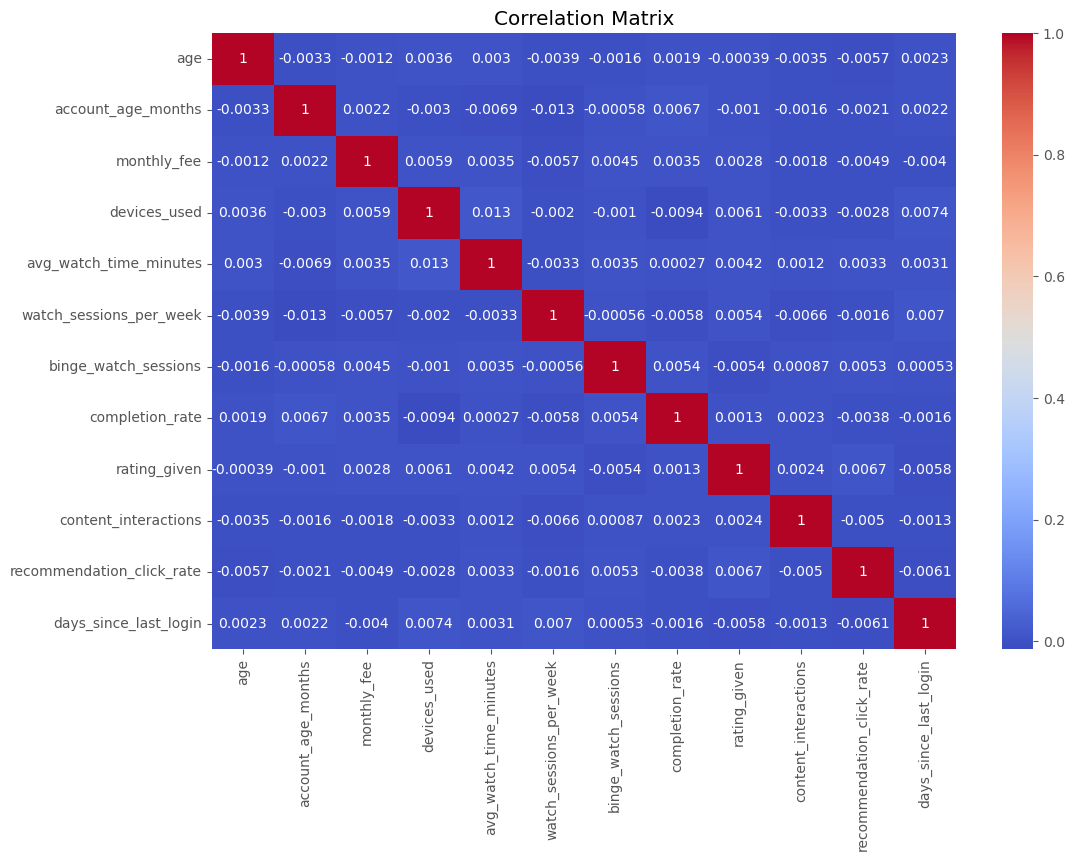

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [13]:
features = [
"age",
"account_age_months",
"monthly_fee",
"devices_used",
"avg_watch_time_minutes",
"watch_sessions_per_week",
"binge_watch_sessions",
"completion_rate",
"rating_given",
"content_interactions",
"recommendation_click_rate",
"days_since_last_login"
]

X = df[features]

y = df["churned"].map({"No":0,"Yes":1})

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
pred = model.predict(X_test)

In [17]:
print("Accuracy:", accuracy_score(y_test, pred))

print(classification_report(y_test, pred))

Accuracy: 0.8046
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      8046
           1       0.00      0.00      0.00      1954

    accuracy                           0.80     10000
   macro avg       0.40      0.50      0.45     10000
weighted avg       0.65      0.80      0.72     10000



C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


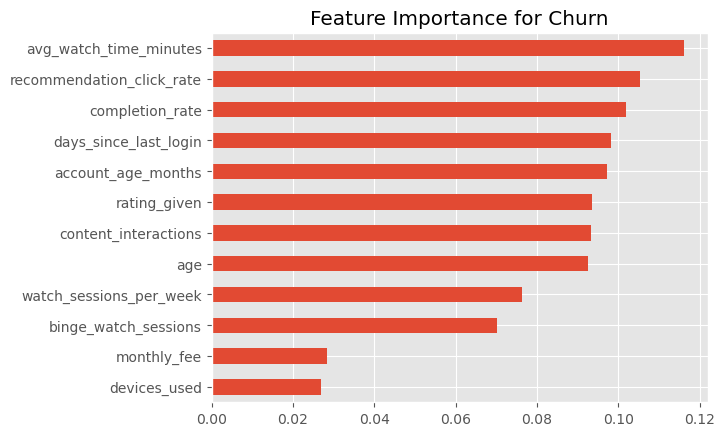

In [18]:
importance = pd.Series(
    model.feature_importances_,
    index=features
)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance for Churn")

plt.show()

In [19]:
print("Average Watch Time:", df["avg_watch_time_minutes"].mean())

print("Average Completion Rate:", df["completion_rate"].mean())

Average Watch Time: 154.94652
Average Completion Rate: 64.53342
